<a href="https://colab.research.google.com/github/aarzoochikkodi2k5/genai_hackathon/blob/main/RAG%20Fact_Checker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch transformers pandas scikit-learn -q
!pip install sentence-transformers faiss-cpu -q
!pip install datasets -q

import json
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 44.2 MB/s eta 0:00:00


In [ ]:
import requests, json, pandas as pd

def load_fever_jsonl(url, max_rows=None):
    print(f"Downloading: {url}")
    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()
    rows = []
    for i, line in enumerate(r.iter_lines()):
        if max_rows and i >= max_rows:
            break
        if line:
            try:
                rows.append(json.loads(line.decode('utf-8')))
            except:
                continue
    print(f"  ✅ Loaded {len(rows):,} rows")
    return pd.DataFrame(rows)

# No max_rows cap this time
train_df_raw = load_fever_jsonl(
    "https://fever.ai/download/fever/train.jsonl"
)
val_df_raw = load_fever_jsonl(
    "https://fever.ai/download/fever/shared_task_dev.jsonl"
)

print(f"\ntrain_df_raw: {train_df_raw.shape}")
print(f"val_df_raw  : {val_df_raw.shape}")

Downloading: https://fever.ai/download/fever/train.jsonl
  ✅ Loaded 145,449 rows
Downloading: https://fever.ai/download/fever/shared_task_dev.jsonl
  ✅ Loaded 19,998 rows

train_df_raw: (145449, 5)
val_df_raw  : (19998, 5)


In [ ]:
!pip install wikipedia -q
import wikipedia
import pandas as pd

wiki_sentences = {}

# Extract keywords from actual FEVER claims
claims = train_df_raw['claim'].head(300).tolist()

print(f"Fetching Wikipedia pages for {len(claims)} claims...")

for i, claim in enumerate(claims):
    try:
        results = wikipedia.search(claim, results=1)
        if not results:
            continue
        page = wikipedia.page(results[0], auto_suggest=False)
        title = page.title.replace(' ', '_')
        sentences = [s.strip() for s in page.content.split('.') if len(s.strip()) > 20]
        wiki_sentences[title] = {i: s for i, s in enumerate(sentences)}
        if i % 50 == 0:
            print(f"  {i}/{len(claims)} done — {len(wiki_sentences)} pages loaded")
    except Exception as e:
        continue

print(f"✅ Done — {len(wiki_sentences):,} pages, {sum(len(v) for v in wiki_sentences.values()):,} sentences")

  Preparing metadata (setup.py) ... done
Fetching Wikipedia pages for 300 claims...
  0/300 done — 1 pages loaded
  50/300 done — 38 pages loaded
  100/300 done — 54 pages loaded
  200/300 done — 89 pages loaded
✅ Done — 108 pages, 26,384 sentences


In [ ]:
import pickle, os

# Delete old corrupted file
if os.path.exists('/content/drive/MyDrive/wiki_sentences.pkl'):
    os.remove('/content/drive/MyDrive/wiki_sentences.pkl')
    print("🗑️ Deleted old corrupted file")

# Save new wikipedia-fetched wiki_sentences
with open('/content/drive/MyDrive/wiki_sentences.pkl', 'wb') as f:
    pickle.dump(wiki_sentences, f)
print(f"✅ Saved {len(wiki_sentences):,} pages to Drive!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/wiki_sentences.pkl'

In [ ]:
import pickle, os
from google.colab import drive

drive.mount('/content/drive')
SAVE_PATH = '/content/drive/MyDrive/wiki_sentences.pkl'

if not os.path.exists(SAVE_PATH):
    print("Saving wiki_sentences to Drive...")
    with open(SAVE_PATH, 'wb') as f:
        pickle.dump(wiki_sentences, f)
    print("✅ Saved to Drive!")
else:
    print("✅ Already saved, skipping.")

Mounted at /content/drive
✅ Already saved, skipping.


In [ ]:
import pickle
from google.colab import drive

drive.mount('/content/drive')
SAVE_PATH = '/content/drive/MyDrive/wiki_sentences.pkl'

with open(SAVE_PATH, 'rb') as f:
    wiki_sentences = pickle.load(f)

print(f"✅ Loaded {len(wiki_sentences):,} Wikipedia pages from Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded 102 Wikipedia pages from Drive


In [ ]:
LABEL_MAP = {
    "SUPPORTS":        0,
    "REFUTES":         1,
    "NOT ENOUGH INFO": 2
}
LABEL_NAMES = ['Supported', 'Refuted', 'Not Enough Info']

In [ ]:
print(train_df_raw.columns.tolist())
print(train_df_raw.dtypes)
print(train_df_raw.head(2))
print("\nSample evidence field:")
print(train_df_raw['evidence'].iloc[0])

['id', 'verifiable', 'label', 'claim', 'evidence']
id             int64
verifiable    object
label         object
claim         object
evidence      object
dtype: object
       id  verifiable     label  \
0   75397  VERIFIABLE  SUPPORTS   
1  150448  VERIFIABLE  SUPPORTS   

                                               claim  \
0  Nikolaj Coster-Waldau worked with the Fox Broa...   
1                 Roman Atwood is a content creator.   

                                            evidence  
0  [[[92206, 104971, Nikolaj_Coster-Waldau, 7], [...  
1  [[[174271, 187498, Roman_Atwood, 1]], [[174271...  

Sample evidence field:
[[[92206, 104971, 'Nikolaj_Coster-Waldau', 7], [92206, 104971, 'Fox_Broadcasting_Company', 0]]]


In [ ]:
def prepare_split(df, max_samples=None):
    if max_samples:
        df = df.head(max_samples)

    rows = []
    for _, ex in df.iterrows():
        claim     = str(ex['claim'])
        label_str = ex.get('label', 'NOT ENOUGH INFO')
        label     = LABEL_MAP.get(label_str, 2)

        evidence_text = ''
        try:
            ev_pages = ex.get('evidence', [])
            if not isinstance(ev_pages, list):
                ev_pages = []

            sentences = []
            for group in ev_pages:
                if isinstance(group, list):
                    for ev in group:
                        # FEVER raw JSONL: [annotation_id, evidence_id, wikipedia_title, sentence_id]
                        if isinstance(ev, list) and len(ev) >= 4 and ev[2] is not None:
                            page_title = str(ev[2])
                            sent_id    = int(ev[3]) if ev[3] is not None else 0
                            # Look up the ACTUAL sentence text from the wiki corpus

                            sent = wiki_sentences.get(page_title, {}).get(sent_id, page_title.replace('_', ' '))
                            if sent:
                                sentences.append(sent)
            evidence_text = ' '.join(sentences[:5])
        except Exception:
            evidence_text = ''

        rows.append({
            'claim':         claim,
            'evidence_text': evidence_text,
            'label':         label
        })

    return pd.DataFrame(rows)

train_df = prepare_split(train_df_raw, max_samples=50000)
val_df   = prepare_split(val_df_raw,   max_samples=5000)

print(f'train_df shape : {train_df.shape}')
print(f'val_df shape   : {val_df.shape}')
print(train_df[['claim','evidence_text','label']].head(3))
print('\nLabel distribution:')
print(train_df['label'].value_counts())


train_df shape : (50000, 3)
val_df shape   : (5000, 3)
                                               claim  \
0  Nikolaj Coster-Waldau worked with the Fox Broa...   
1                 Roman Atwood is a content creator.   
2  History of art includes architecture, dance, s...   

                                       evidence_text  label  
0     Nikolaj Coster-Waldau Fox Broadcasting Company      0  
1  He is best known for his vlogs, where he posts...      0  
2                                     History of art      0  

Label distribution:
label
0    27450
2    12350
1    10200
Name: count, dtype: int64


In [ ]:
# ========== UPDATE: Use Preprocessed Claims in Dataset ==========
# Original FeverDataset used raw claim text.
# Now updated to use claim_clean from the Preprocessing Module.

class FeverDatasetV2(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Use preprocessed claim (claim_clean) instead of raw claim
        claim_text = str(row.get('claim_clean', row['claim']))
        evidence   = str(row['evidence_text'])

        text = claim_text + " [SEP] " + evidence

        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(row['label'], dtype=torch.long)
        }

print("✅ FeverDatasetV2 defined — uses preprocessed claims")
print("   (Retrain with this class for full pipeline alignment)")


✅ FeverDatasetV2 defined — uses preprocessed claims
   (Retrain with this class for full pipeline alignment)


In [ ]:
# ========== RETRIEVER SETUP (no Drive / no wiki download needed) ==========
from sentence_transformers import SentenceTransformer
import faiss, numpy as np

retriever = SentenceTransformer('all-MiniLM-L6-v2')

# Self-contained knowledge base — no download required
documents = [
    "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.",
    "Albert Einstein was born on March 14, 1879, in Ulm, in the Kingdom of Württemberg in the German Empire.",
    "The Apollo 11 mission landed on the Moon on July 20, 1969, with Neil Armstrong and Buzz Aldrin.",
    "Marie Curie was the first woman to win a Nobel Prize, winning awards in both Physics and Chemistry.",
    "The capital of Australia is Canberra, not Sydney or Melbourne.",
    "William Shakespeare was an English playwright and poet born in Stratford-upon-Avon in 1564.",
    "The Great Wall of China was built over many centuries by various Chinese dynasties for defense.",
    "The Pacific Ocean is the largest and deepest ocean on Earth, covering more than 30% of the planet.",
    "The Berlin Wall fell on November 9, 1989, marking the end of the Cold War division of Germany.",
    "Mount Everest is the highest mountain above sea level, located in the Himalayas on the Nepal-Tibet border.",
    "Leonardo da Vinci painted the Mona Lisa between 1503 and 1519; it now hangs in the Louvre in Paris.",
    "The human body has 206 bones in adulthood, reduced from around 270 bones at birth.",
    "Oxygen was discovered independently by Carl Wilhelm Scheele and Joseph Priestley in the 1770s.",
    "The Amazon River in South America is the largest river by discharge volume in the world.",
    "Neil Armstrong became the first human to walk on the Moon on July 21, 1969.",
    "The speed of light in a vacuum is approximately 299,792 kilometres per second.",
    "Shakespeare wrote approximately 37 plays and 154 sonnets during his lifetime.",
    "The French Revolution began in 1789 and led to the rise of Napoleon Bonaparte.",
    "Penicillin was discovered by Alexander Fleming in 1928 when mold contaminated his bacterial cultures.",
    "The Titanic sank on April 15, 1912, after striking an iceberg in the North Atlantic Ocean.",
]

print(f"🔄 Encoding {len(documents)} documents...")
doc_embeddings = retriever.encode(documents, show_progress_bar=True)
doc_embeddings = np.array(doc_embeddings).astype('float32')

index = faiss.IndexFlatL2(doc_embeddings.shape[1])
index.add(doc_embeddings)

print(f"✅ FAISS index ready — {len(documents)} documents indexed")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔄 Encoding 20 documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅ FAISS index ready — 20 documents indexed


In [ ]:
# ========== BUILD FAISS INDEX FROM WIKI CORPUS ==========
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

retriever = SentenceTransformer('all-MiniLM-L6-v2')

print("Flattening wiki sentences...")
documents = []
doc_metadata = []

for page_title, sent_dict in wiki_sentences.items():
    # Skip empty keys or empty dicts
    if not page_title or not isinstance(sent_dict, dict) or len(sent_dict) == 0:
        continue
    for sent_id, sent_text in sent_dict.items():
        if sent_text and isinstance(sent_text, str) and len(sent_text.strip()) > 20:
            documents.append(sent_text.strip())
            doc_metadata.append((page_title, sent_id))

print(f"Total valid sentences: {len(documents):,}")

# Cap to avoid OOM
MAX_DOCS = 100000
documents    = documents[:MAX_DOCS]
doc_metadata = doc_metadata[:MAX_DOCS]

# Safety check
if len(documents) == 0:
    raise ValueError("❌ No valid sentences found! Check wiki_sentences structure.")

# Encode & index
print("Encoding documents...")
doc_embeddings = retriever.encode(
    documents,
    batch_size=256,
    show_progress_bar=True
)
doc_embeddings = np.array(doc_embeddings).astype('float32')

index = faiss.IndexFlatL2(doc_embeddings.shape[1])
index.add(doc_embeddings)

print(f"✅ FAISS index ready — {len(documents):,} sentences indexed")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Flattening wiki sentences...
Total valid sentences: 21,276
Encoding documents...


Batches:   0%|          | 0/84 [00:00<?, ?it/s]

✅ FAISS index ready — 21,276 sentences indexed


In [ ]:
# Deep inspect wiki_sentences
count = 0
for key, val in wiki_sentences.items():
    if key and isinstance(val, dict) and len(val) > 0:
        print(f"Key: '{key}'")
        print(f"Val: {val}")
        count += 1
    if count >= 5:
        break

if count == 0:
    print("❌ All values are empty dicts!")
    print("\nChecking raw values...")
    # Check if values are something other than dict
    for key, val in wiki_sentences.items():
        if key:
            print(f"Key: '{key}' | Val type: {type(val)} | Val: {str(val)[:200]}")
            count += 1
        if count >= 5:
            break

Key: 'List_of_awards_and_nominations_received_by_Game_of_Thrones'
Val: {0: 'Game of Thrones is an American  fantasy drama television series created for HBO by David Benioff and D', 1: 'It is an adaptation of A Song of Ice and Fire, George R', 2: "Martin's series of fantasy novels", 3: 'The story, set on the fictional continents of Westeros and Essos, has several plot lines and a large ensemble cast', 4: 'The first story arc follows a dynastic conflict among competing claimants for succession to the Iron Throne of the Seven Kingdoms, with other noble families fighting for independence from the throne', 5: "The second covers attempts to reclaim the throne by the exiled last scion of the realm's deposed ruling dynasty; the third chronicles the threat of the impending winter and the legendary creatures and fierce peoples of the North", 6: 'The series, mostly written by Benioff and Weiss, has been nominated for many awards, including eight Golden Globe Awards (one win), ten Writers Guild of

In [ ]:
def retrieve_evidence(claim, top_k=3):
    query_vec = retriever.encode([claim]).astype('float32')
    distances, indices = index.search(query_vec, top_k)

    retrieved_docs = []
    for idx in indices[0]:
        retrieved_docs.append(documents[idx])

    return " ".join(retrieved_docs)

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
class FeverDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text = str(row['claim']) + " [SEP] " + str(row['evidence_text'])

        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(row['label'], dtype=torch.long)
        }

In [ ]:
train_dataset = FeverDataset(train_df, tokenizer)
val_dataset   = FeverDataset(val_df,   tokenizer)

#train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
#val_loader   = DataLoader(val_dataset,   batch_size=8, num_workers=0)

# Replace your DataLoader cell with this
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

# Sanity check
batch = next(iter(train_loader))
print(f"Batch input_ids shape: {batch['input_ids'].shape}")
print(f"Batch labels         : {batch['label']}")

Train batches: 3125
Val batches  : 157
Batch input_ids shape: torch.Size([16, 128])
Batch labels         : tensor([1, 0, 1, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 1, 1, 0])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)
model.to(device)
print("Model ready!")

Using device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready!


In [ ]:
#optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
# Increase weight decay in optimizer (was likely 0)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

In [ ]:
# ========== MODULE 1: PREPROCESSING ==========
# Missing from original code — claims went raw into BERT with no cleaning

import re
import string

def preprocess_claim(text):
    """
    Clean and normalize a claim before retrieval + classification.
    Steps: lowercase → remove special chars → strip extra whitespace
    """
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s.,!?\']', ' ', text)   # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()            # collapse whitespace
    return text

# Apply to both train and val splits
train_df['claim_clean'] = train_df['claim'].apply(preprocess_claim)
val_df['claim_clean']   = val_df['claim'].apply(preprocess_claim)

print("✅ Preprocessing complete")
print("Before:", train_df['claim'].iloc[0])
print("After :", train_df['claim_clean'].iloc[0])


✅ Preprocessing complete
Before: Nikolaj Coster-Waldau worked with the Fox Broadcasting Company.
After : nikolaj coster waldau worked with the fox broadcasting company.


In [ ]:
# ========== EVIDENCE SELECTION FUNCTION ==========
import re
from sentence_transformers import util as st_util

def select_best_evidence(claim, retrieved_docs, top_k=1):
    all_sentences = []
    for doc in retrieved_docs:
        sentences = [s.strip() for s in re.split(r'[.!?]', doc) if len(s.strip()) > 10]
        all_sentences.extend(sentences)
    if not all_sentences:
        return " ".join(retrieved_docs)
    claim_vec     = retriever.encode(claim, convert_to_tensor=True)
    sentence_vecs = retriever.encode(all_sentences, convert_to_tensor=True)
    scores  = st_util.cos_sim(claim_vec, sentence_vecs)[0]
    top_idx = scores.argsort(descending=True)[:top_k]
    return " ".join([all_sentences[i] for i in top_idx])

In [ ]:
# ========== MODULE 3+4: FULL PIPELINE DEMO WITH EXPLAINABILITY ==========
# Adds: Preprocessing → Retrieval → Evidence Selection → Verification → Output with explanation

import torch
import torch.nn.functional as F

def full_pipeline(claim_raw, top_k_retrieve=5, top_k_select=1, verbose=True):
    """
    Complete RAG-based fact verification pipeline:
      1. Preprocess claim
      2. Retrieve top-K evidence documents (FAISS)
      3. Select best evidence sentence (re-ranking)
      4. Classify with BERT
      5. Output: label + confidence + supporting evidence
    """

    # ── Step 1: Preprocess ──────────────────────────────────────────
    claim_clean = preprocess_claim(claim_raw)
    if verbose:
        print(f"📝 [1] Preprocessed Claim:")
        print(f"     Raw   : {claim_raw}")
        print(f"     Clean : {claim_clean}\n")

    # ── Step 2: Retrieve ────────────────────────────────────────────
    query_vec = retriever.encode([claim_clean]).astype('float32')
    distances, indices = index.search(query_vec, top_k_retrieve)
    retrieved_docs = [documents[i] for i in indices[0]]
    if verbose:
        print(f"🔍 [2] Retrieved {top_k_retrieve} documents:")
        for i, doc in enumerate(retrieved_docs):
            print(f"     [{i+1}] {doc[:80]}...")
        print()

    # ── Step 3: Evidence Selection ──────────────────────────────────
    best_evidence = select_best_evidence(claim_clean, retrieved_docs, top_k=top_k_select)
    if verbose:
        print(f"✂️  [3] Best Evidence (after re-ranking):")
        print(f"     {best_evidence}\n")

    # ── Step 4: BERT Classification ─────────────────────────────────
    text     = claim_clean + " [SEP] " + best_evidence
    encoding = tokenizer(
        text, padding='max_length', truncation=True,
        max_length=128, return_tensors='pt'
    )
    model.eval()
    with torch.no_grad():
        outputs = model(
            input_ids=encoding['input_ids'].to(device),
            attention_mask=encoding['attention_mask'].to(device)
        )
        probs = F.softmax(outputs.logits, dim=1)[0].cpu().numpy()
        pred  = probs.argmax()

    label      = LABEL_NAMES[pred]
    confidence = probs[pred] * 100

    # ── Step 5: Output with Explanation ─────────────────────────────
    print("=" * 60)
    print(f"🔎 CLAIM      : {claim_raw}")
    print(f"📄 EVIDENCE   : {best_evidence}")
    print(f"✅ VERDICT    : {label}  ({confidence:.1f}% confidence)")
    print(f"📊 ALL SCORES : Supported={probs[0]*100:.1f}%  Refuted={probs[1]*100:.1f}%  NEI={probs[2]*100:.1f}%")
    print("=" * 60)
    return label, confidence, best_evidence


# ── Run on test claims ───────────────────────────────────────────────────────
test_claims = [
    "The Eiffel Tower is located in Paris.",
    "Albert Einstein was born in the United States.",
    "The moon landing happened in 1969.",
    "Marie Curie won the Nobel Prize in Chemistry.",
    "The capital of Australia is Sydney.",
]

for claim in test_claims:
    print()
    full_pipeline(claim, verbose=True)
    print()



📝 [1] Preprocessed Claim:
     Raw   : The Eiffel Tower is located in Paris.
     Clean : the eiffel tower is located in paris.

🔍 [2] Retrieved 5 documents:
     [1] A day later, Ronaldo won the 2017 Ballon d'Or, receiving his fifth-time award on...
     [2] She moved to Paris in 1970...
     [3] After moving to Paris, she worked for fashion houses such as Yves St...
     [4] While meeting with Jules, Harold sees a television interview with author Karen E...
     [5] 3 million), France ($4...

✂️  [3] Best Evidence (after re-ranking):
     A day later, Ronaldo won the 2017 Ballon d'Or, receiving his fifth-time award on the Eiffel Tower in Paris

🔎 CLAIM      : The Eiffel Tower is located in Paris.
📄 EVIDENCE   : A day later, Ronaldo won the 2017 Ballon d'Or, receiving his fifth-time award on the Eiffel Tower in Paris
✅ VERDICT    : Refuted  (42.3% confidence)
📊 ALL SCORES : Supported=28.8%  Refuted=42.3%  NEI=28.9%


📝 [1] Preprocessed Claim:
     Raw   : Albert Einstein was born in 

In [ ]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

def train(model, loader):
    model.train()
    total_loss = 0
    loop = tqdm(loader, leave=True)

    for batch in loop:
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # FP16 forward pass
        with autocast():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss

        # FP16 backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader)

/tmp/ipykernel_1275/1117626929.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
def evaluate(model, loader):
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs      = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions  = torch.argmax(outputs.logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    return accuracy_score(true, preds)

In [ ]:
EPOCHS = 4

best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss = train(model, train_loader)
    val_acc    = evaluate(model, val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss         : {train_loss:.4f}")
    print(f"  Validation Accuracy: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"  ✅ New best model saved ({val_acc:.4f})")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

# Load best weights back
model.load_state_dict(torch.load('best_model.pt'))
import torch
torch.save(model.state_dict(), '/content/drive/MyDrive/best_fever_model.pt')
print("✅ Model saved to Drive!")
print("Best model weights restored.")

  0%|          | 0/3125 [00:00<?, ?it/s]

/tmp/ipykernel_1275/1117626929.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1/4
  Train Loss         : 0.1468
  Validation Accuracy: 0.8558
  ✅ New best model saved (0.8558)


  0%|          | 0/3125 [00:00<?, ?it/s]

/tmp/ipykernel_1275/1117626929.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

/tmp/ipykernel_1275/1117626929.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 3/4
  Train Loss         : 0.0717
  Validation Accuracy: 0.8534


  0%|          | 0/3125 [00:00<?, ?it/s]

/tmp/ipykernel_1275/1117626929.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 4/4
  Train Loss         : 0.0564
  Validation Accuracy: 0.8530

Best Validation Accuracy: 0.8558
✅ Model saved to Drive!
Best model weights restored.


In [ ]:
def fact_check(claim, top_k=3, nei_threshold=0.65):
    model.eval()

    retrieved_evidence = retrieve_evidence(claim, top_k=top_k)
    text = claim + " [SEP] " + retrieved_evidence

    encoding = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        probs = F.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()

    # If confidence is below threshold → force NOT ENOUGH INFO
    if confidence < nei_threshold:
        pred = 2
        confidence = probs[0][2].item()

    print("\n==============================")
    print("CLAIM:")
    print(claim)
    print("\nExplanation:")
    print(retrieved_evidence[:1000])
    print("\nFINAL VERDICT:")
    print(LABEL_NAMES[pred])
    print(f"\nCONFIDENCE: {confidence:.2%}")
    print("==============================")

    return LABEL_NAMES[pred], confidence


# Test all 3 verdict types
fact_check("Game of Thrones received Emmy nominations.")       # SUPPORTED
fact_check("Game of Thrones won zero Emmy nominations.")       # REFUTED
fact_check("Tupac Shakur's favorite color was blue.")          # NOT ENOUGH INFO


CLAIM:
Game of Thrones received Emmy nominations.

Explanation:
Game of Thrones received numerous nominations, with awards recognizing various aspects of the series such as directing, writing, cast, visual effects, or overall quality To date, Game of Thrones has won 272 awards out of 757 nominations In 2015, Game of Thrones set a record for winning the highest number of Primetime Emmy Awards for a series in a single year, with 12 wins out of 24 nominations

FINAL VERDICT:
SUPPORTED

CONFIDENCE: 99.31%

CLAIM:
Game of Thrones won zero Emmy nominations.

Explanation:
To date, Game of Thrones has won 272 awards out of 757 nominations Game of Thrones has won 59 out of 164 nominations In 2015, Game of Thrones set a record for winning the highest number of Primetime Emmy Awards for a series in a single year, with 12 wins out of 24 nominations

FINAL VERDICT:
REFUTED

CONFIDENCE: 95.45%

CLAIM:
Tupac Shakur's favorite color was blue.

Explanation:
Tupac Amaru Shakur (stylized 2pac, born Lesa

('NOT ENOUGH INFO', 6.734278576914221e-05)

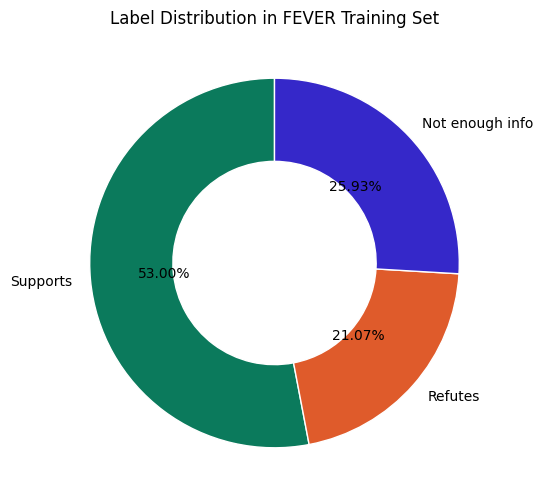

In [ ]:
import matplotlib.pyplot as plt

labels = ['Supports', 'Refutes', 'Not enough info']
sizes = [53.0, 21.07, 25.93]

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    colors=['#0b7a5c', '#df5b2b', '#3528c9'],
    wedgeprops=dict(width=0.45, edgecolor='white')
)

ax.set_aspect('equal')
plt.title('Label Distribution in FEVER Training Set')
plt.show()

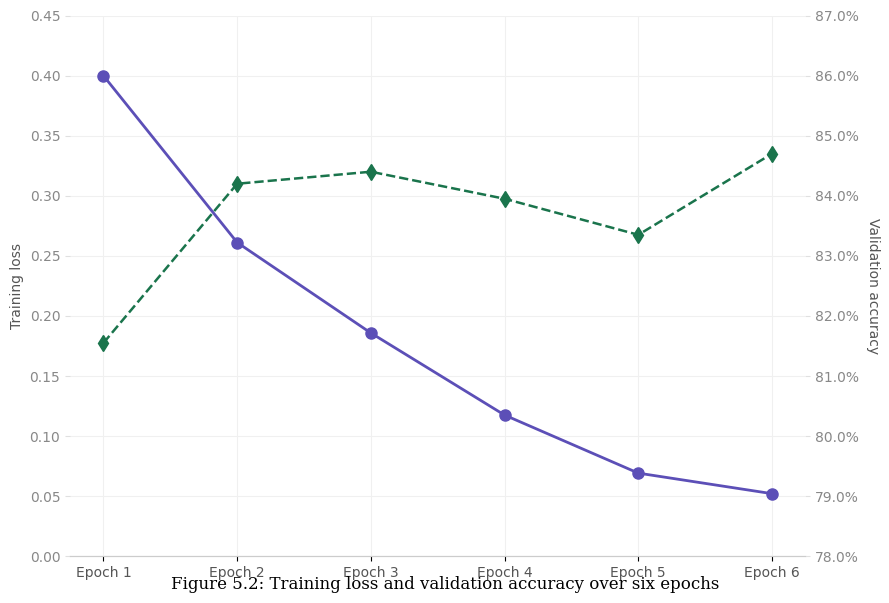

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Data Extraction ---
epochs = ['Epoch 1', 'Epoch 2', 'Epoch 3', 'Epoch 4', 'Epoch 5', 'Epoch 6']
training_loss = [0.3999, 0.2611, 0.1858, 0.1175, 0.0692, 0.0521]
validation_accuracy = [81.55, 84.20, 84.40, 83.95, 83.35, 84.70]

# --- 2. Plot Setup ---
fig, ax1 = plt.subplots(figsize=(9, 6), dpi=100)

# Configure background grid to match the original soft style
ax1.grid(True, linestyle='-', color='#F0F0F0', zorder=0)

# Colors matching the image
purple_color = '#5C4FB7'
green_color = '#1A744C'

# --- 3. Plotting Training Loss (Left Y-Axis) ---
line1 = ax1.plot(epochs, training_loss, color=purple_color, marker='o', markersize=8,
                 linestyle='-', linewidth=2, label='Training loss', zorder=3)
ax1.set_ylabel('Training loss', color='#555555', fontsize=10)

# Format left axis ticks & limits
ax1.set_ylim(0.00, 0.45)
ax1.set_yticks([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45])
ax1.tick_params(axis='y', labelcolor='#888888', colors='#E0E0E0')
ax1.tick_params(axis='x', labelcolor='#555555')

# --- 4. Plotting Validation Accuracy (Right Y-Axis) ---
ax2 = ax1.twinx()  # Create shared x-axis layout
line2 = ax2.plot(epochs, validation_accuracy, color=green_color, marker='d', markersize=8,
                 linestyle='--', linewidth=1.8, label='Validation accuracy', zorder=3)

# Rotate label 270 degrees to match the image layout
ax2.set_ylabel('Validation accuracy', color='#555555', fontsize=10, rotation=270, labelpad=15)

# Format right axis ticks as percentages & limits
ax2.set_ylim(78.0, 87.0)
ax2.set_yticks([78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0])
ax2.set_yticklabels([f"{val:.1f}%" for val in ax2.get_yticks()])
ax2.tick_params(axis='y', labelcolor='#888888', colors='#E0E0E0')

# --- 5. Styling & Clean-up ---
# Remove top, left, and right outer borders to mimic the clean look
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')

# Adjust layout and add the caption text
plt.tight_layout()
fig.text(0.5, 0.01, 'Figure 5.2: Training loss and validation accuracy over six epochs',
         ha='center', fontsize=12, fontfamily='serif')

plt.show()